# Visualizing Error Distributions with ECDF Plots

Aggregate error statistics such as RMSE or MUE provide a useful summary of prediction quality, but they can hide important information about the **distribution** of errors. An **Empirical Cumulative Distribution Function (ECDF)** plot addresses this by showing what fraction of predictions fall within a given error threshold.

For example, an ECDF plot lets you quickly answer questions like:

- What percentage of my ΔΔG predictions have an absolute error below 1 kcal/mol?
- How does Method A compare to Method B across the full error distribution, not just on average?

## FEMaps and multiple method comparisons

The core principle in ``cinnabar`` is **one** ``FEMap`` per unique ligand series / protein target. When comparing multiple computational methods on the same series, each method's results should be added to the *same* ``FEMap`` under a different ``source`` label, this allows the high-level plotting functions to automatically detect and compare them.

In this tutorial, we walk step-by-step through the construction of a single ``FEMap`` with multiple result sources and demonstrate how we can use the ECDF plotting functionality in ``Cinnabar`` to compare their performance against experimental data.

We will then introduce the base ``ecdf_plot`` function which can be used to aggregate performance across multiple systems (see the [Comparing across multiple systems](#comparing-across-multiple-systems) section at the end).

## Setting Up the FEMap

We start by constructing a single ``FEMap`` from the included example data generated with [OpenFE](https://docs.openfree.energy/en/latest/).
**Both** methods' calculations are added to the same ``FEMap``, each under a different ``source`` label to distinguish them. The experimental measurements are also added to the same map, allowing for direct comparison.

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
from openff.units import unit

from cinnabar import FEMap, plotting

# load the computational results
rbfe_results = pd.read_csv("../cinnabar/data/computational_data.csv")

# set the random seed for reproducibility - i.e. bootstrap resampling and method B's added noise
rng = np.random.default_rng(seed=42)

# One FEMap for this ligand series
femap = FEMap()

# Method A: the original calculated values
for _, result in rbfe_results.iterrows():
    # add each calculated relative free energy to the FEMap
    femap.add_relative_calculation(
        labelA=result["Ligand1"],  # string identifier for ligandA
        labelB=result["Ligand2"],  # string identifier for ligandB
        value=result["calc_DDG"] * unit.kilocalorie_per_mole,  # the calculated relative free energy with units
        uncertainty=result["calc_dDDG(MBAR)"]
        * unit.kilocalorie_per_mole,  # the uncertainty in the calculated relative free energy with units
        source="Method A",  # optional string describing the source of the calculation
    )

# Method B: same edges, slightly different values (simulating a second protocol)
for _, result in rbfe_results.iterrows():
    # add each calculated relative free energy to the FEMap
    femap.add_relative_calculation(
        labelA=result["Ligand1"],
        labelB=result["Ligand2"],
        # add ±0.5 kcal/mol noise
        value=(result["calc_DDG"] + rng.normal(0, 0.5)) * unit.kilocalorie_per_mole,
        uncertainty=result["calc_dDDG(MBAR)"] * unit.kilocalorie_per_mole,
        source="Method B",
    )

# Experimental absolute values (shared by both methods)
experimental_results = pd.read_csv("../cinnabar/data/experimental_data.csv")
for _, exp_row in experimental_results.iterrows():
    femap.add_experimental_measurement(
        label=exp_row["Ligand"],
        value=exp_row["expt_DG"] * unit.kilocalorie_per_mole,
        uncertainty=exp_row["expt_dDG"] * unit.kilocalorie_per_mole,
        source="Experimental",
    )

# Generate MLE absolute values for both sources in one call.
# This produces sources "MLE(Method A)" and "MLE(Method B)" in the absolute dataframe.
femap.generate_absolute_values()
print(f"FEMap contains {femap.n_ligands} ligands")
rel_df = femap.get_relative_dataframe()
print("Computational sources:", rel_df.loc[rel_df["computational"], "source"].unique().tolist())

FEMap contains 36 ligands
Computational sources: ['Method A', 'Method B']


## ECDF of Edgewise ΔΔG Errors

``ecdf_plot_DDGs`` plots the empirical CDF of **absolute errors** for each directly simulated relative free energy edge. The error is computed as ``|ΔΔG_calc − ΔΔG_exp|``, where the experimental ΔΔG values are taken from the experimental measurements added to the FEMap.

This is the most direct assessment of how well your RBFE calculations reproduce experimental ΔΔG values for the specific transformations you chose to simulate.

The function automatically detects all computational sources in the FEMap and plots one curve per source.

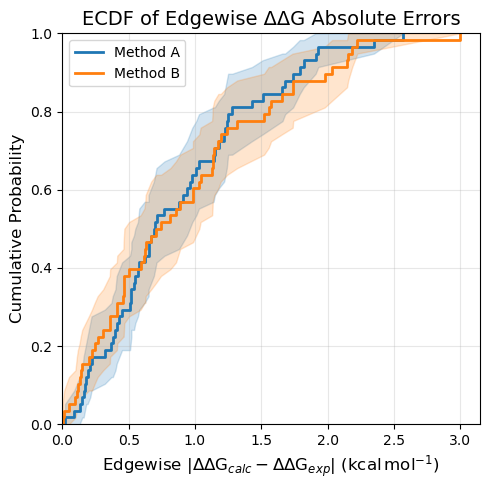

In [2]:
# Both sources are plotted automatically, the figure is also returned for further customization if needed
fig = plotting.ecdf_plot_DDGs(
    femap,
    title="ECDF of Edgewise ΔΔG Absolute Errors",
    figsize=5,
)

ECDF plots include an estimate of the 95% confidence interval by default. This is generated via a bootstrapping procedure where the ECDF is calculated for each bootstrap iteration and values for the confidence interval are obtained from the distribution of ECDFs. This can be disabled by setting ``nbootstraps=0`` in any of the plots.

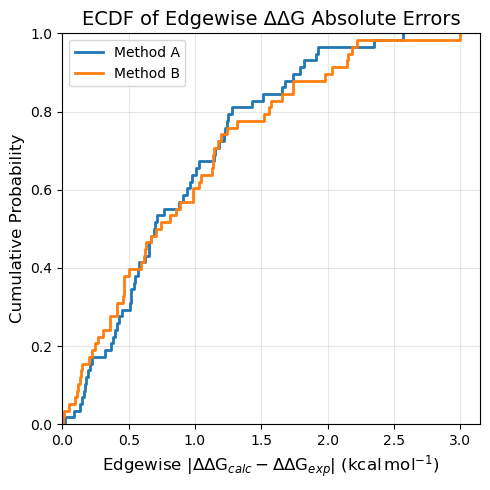

In [3]:
# Turn off the CI estimates
fig = plotting.ecdf_plot_DDGs(
    femap,
    title="ECDF of Edgewise ΔΔG Absolute Errors",
    figsize=5,
    nbootstraps=0,
)

You can also specify a subset explicitly. This is useful if your FEMap contains many sources but you only want to compare a few of them, or if you want to provide custom display labels.

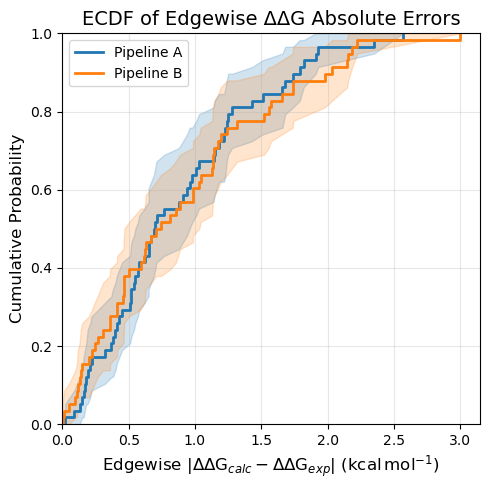

In [4]:
# Explicit source selection with custom display labels
fig = plotting.ecdf_plot_DDGs(
    femap,
    sources=["Method A", "Method B"],
    labels=["Pipeline A", "Pipeline B"],
    title="ECDF of Edgewise ΔΔG Absolute Errors",
    figsize=5,
)

<div class="alert alert-block alert-info"> <b>Note</b> The ECDF curve starting closer to the upper-left corner indicates better performance as a larger fraction of predictions fall within a small error threshold. </div>


## ECDF of Nodewise ΔG Errors

``ecdf_plot_DGs`` plots the empirical CDF of **absolute errors** in the estimated absolute free energies (ΔG) for each ligand, using computational values either backcalculated from relative calculations (by default using MLE) or from directly simulated estimates in the ``FEMap``. The error is computed as ``|ΔG_calc − ΔG_exp|``, where the experimental ΔG values are taken from the experimental measurements added to the FEMap.

Both the calculated and experimental ΔG values are centered around zero before computing absolute errors (controlled by the ``centralizing`` parameter), removing the arbitrary offset introduced by the MLE reconstruction.

In the case of backcalculated values generated via ``generate_absolute_values()``, the absolute dataframe contains ``MLE(Method A)`` and ``MLE(Method B)`` sources, which are detected and plotted automatically. Note that the MLE reconstruction is based on the simulated edges, so the nodewise ΔG errors are not independent of the edgewise ΔΔG errors.

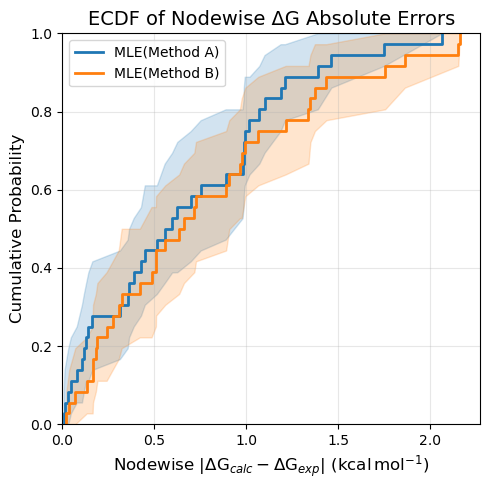

In [5]:
fig = plotting.ecdf_plot_DGs(
    femap,
    title="ECDF of Nodewise ΔG Absolute Errors",
    figsize=5,
)

## ECDF of All-to-All Pairwise ΔΔG Errors

``ecdf_plot_all_DDGs`` computes **all pairwise ΔΔG values** using computational absolute ΔG values either backcalculated from relative calculations (by default using MLE) or from directly simulated estimates in the ``FEMap``. The error is computed as ``|ΔΔG_calc − ΔΔG_exp|``, where the experimental ΔΔG values are derived from the experimental ΔG values added to the FEMap.

This has two key advantages over ``ecdf_plot_DDGs``:

- **Network-independent**: Different methods may have used different transformation graphs. By reconstructing all ΔΔGs from absolute values, you can compare on a **common set** of predictions.
- **More comprehensive**: Every ligand pair is included, giving a complete picture of performance across the series, though this increases the sensitivity to outliers.

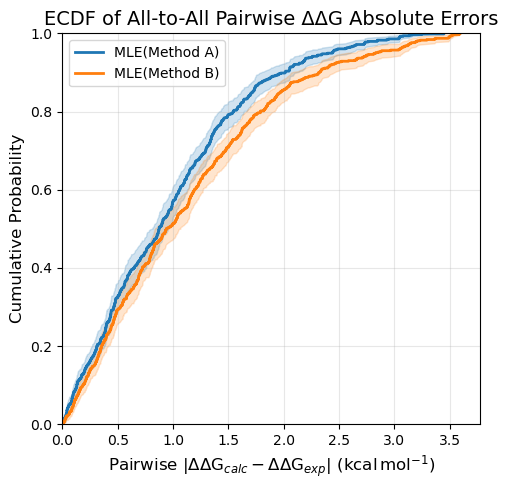

In [6]:
fig = plotting.ecdf_plot_all_DDGs(
    femap,
    title="ECDF of All-to-All Pairwise ΔΔG Absolute Errors",
    figsize=5,
)

## Comparing across multiple systems

The three plotting functions above compare sources **within** a single FEMap (one ligand series / protein target). When you want to compare the **same method across several different targets**, each target has its own separate ``FEMap`` and you can aggregate errors yourself using the underlying DataFrames.

The pattern is:

1. Iterate over your target FEMaps.
2. Call ``get_relative_dataframe()`` (edgewise ΔΔG) or ``get_absolute_dataframe()`` (nodewise ΔG).
3. Filter to the source of interest, join with experimental values, compute ``|calc − exp|``.
4. Collect into a ``dict[label → errors]`` and pass to ``ecdf_plot``.

### Edgewise ΔΔG: cross-target comparison

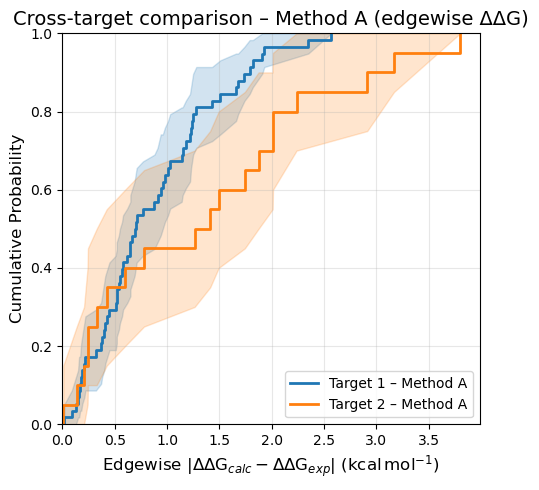

In [7]:
# Here we will make a second FEMap with random data for illustration

target_2 = FEMap()
for i in range(1, 21):
    # create a radial network
    target_2.add_relative_calculation(
        labelA=f"Ligand0",
        labelB=f"Ligand{i}",
        value=rng.normal(0, 1) * unit.kilocalorie_per_mole,
        uncertainty=0.2 * unit.kilocalorie_per_mole,
        source="Method A",
    )
    target_2.add_experimental_measurement(
        label=f"Ligand{i}",
        value=rng.normal(-8, 2) * unit.kilocalorie_per_mole,
        uncertainty=0.5 * unit.kilocalorie_per_mole,
        source="Experimental",
    )
# add the central ligand value
target_2.add_experimental_measurement(
    label=f"Ligand0",
    value=-9 * unit.kilocalorie_per_mole,
    uncertainty=0.5 * unit.kilocalorie_per_mole,
    source="Experimental",
)

target_femaps = {
    "Target 1": femap,
    "Target 2": target_2,
}

# extract the data for Method A only across the targets
METHOD = "Method A"

datasets = {}
for target_name, fm in target_femaps.items():
    df = fm.get_relative_dataframe()
    exp_df = (
        df[~df["computational"]]
        .drop_duplicates(subset=["labelA", "labelB"])
        .set_index(["labelA", "labelB"])[["DDG (kcal/mol)"]]
        .rename(columns={"DDG (kcal/mol)": "DDG_exp"})
    )
    comp_df = df[df["computational"] & (df["source"] == METHOD)].set_index(["labelA", "labelB"])[["DDG (kcal/mol)"]]
    merged = comp_df.join(exp_df, how="left").dropna(subset=["DDG_exp"])
    datasets[f"{target_name} – {METHOD}"] = np.abs(merged["DDG (kcal/mol)"] - merged["DDG_exp"]).values

fig = plotting.ecdf_plot(
    datasets=datasets,
    title=f"Cross-target comparison – {METHOD} (edgewise ΔΔG)",
    xlabel="Edgewise",
    figsize=5,
)

## Customisation

All ECDF functions share a common set of customisation options via ``ecdf_plot``:

- ``colors``: a list of colors (one per source/dataset) to override the default palette.
- ``figsize``: either a single float (square figure) or a ``(width, height)`` tuple.
- ``title``: set to ``None`` to suppress the title entirely.
- ``ecdf_kwargs``: a dict passed directly to ``seaborn.ecdfplot`` (e.g., to change line style or width).
- ``filename``: if provided, the figure is saved to this path.

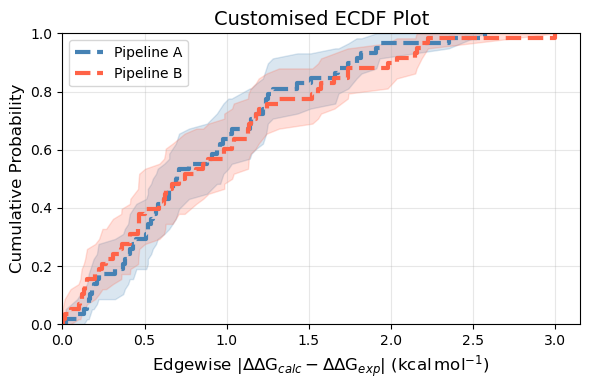

In [8]:
fig = plotting.ecdf_plot_DDGs(
    femap,
    sources=["Method A", "Method B"],
    labels=["Pipeline A", "Pipeline B"],
    title="Customised ECDF Plot",
    figsize=(6, 4),
    colors=["steelblue", "tomato"],
    ecdf_kwargs={"linewidth": 3, "linestyle": "--"},
)

## Recap

- ECDF plots show the **full distribution** of prediction errors, complementing aggregate statistics like RMSE and MUE.
- Use **one** ``FEMap`` per ligand series. Add different methods as different ``source`` labels within the same FEMap.
- ``ecdf_plot_DDGs``, ``ecdf_plot_DGs``, and ``ecdf_plot_all_DDGs`` each accept a single ``FEMap`` and compare its sources automatically.
- ``ecdf_plot_DGs`` and ``ecdf_plot_all_DDGs`` require ``femap.generate_absolute_values()`` to have been called first or simulated absolute free energy estimates to be added to the ``FEMap``.
- To compare the same method **across multiple protein targets**, use the low-level ``ecdf_plot`` directly, extracting error arrays via ``get_relative_dataframe()`` or ``get_absolute_dataframe()``.